In [111]:

import torch
import pyro
import pyro.distributions as dist
import pyro.contrib.gp as gp
from pyro.infer import MCMC, NUTS, HMC
from IPython.core.pylabtools import figsize
import numpy as np
import pandas as pd

from pathlib import Path
import glob
from matplotlib import pyplot as plt
from scipy.stats.mstats import mquantiles
from sklearn.preprocessing import MinMaxScaler
from pyro.infer.autoguide import init_to_value



# Parameter determination for function
We specify a bi-Lorentzian model for the ODMR spectra where the mean values change is driven by a learned linear function that depends on temperature. In the first part, we learn the parameters of the linear "calibration" function that maps the peak center positions on to temperature. From previous experiment we know that the model is underspecified. Here we add an additional affine transfomation on the output of the probablistic model. This learned model with calibration added is referred to as the calibrated_model-  it is then subsequently used to predict temperatures given spectra and associated uncertainty in the predicted value.

## Set up function
Here we import the data, define a bi-Lorentzian function and demonstrate the impact of different values of center 1 and center 2 (A and B, respectively) on the simulated spectra.

In [112]:
temps_ = ['-30', '-20', '-10', '0',
       '10', '20', '30', '40', '50', '40', '30', '20',
       '10', '0', '-10', '-20', '-30']

temps = np.array(temps_, dtype=float)

temps = temps + 273.15  # Convert to Kelvin

temps = torch.tensor(temps).double()

temps = temps[:9]

temp_test_array = np.array(temps_, dtype=float) + 273.15  # Convert to Kelvin
temp_test = torch.tensor(temp_test_array).double()

In [113]:
len(temps)


9

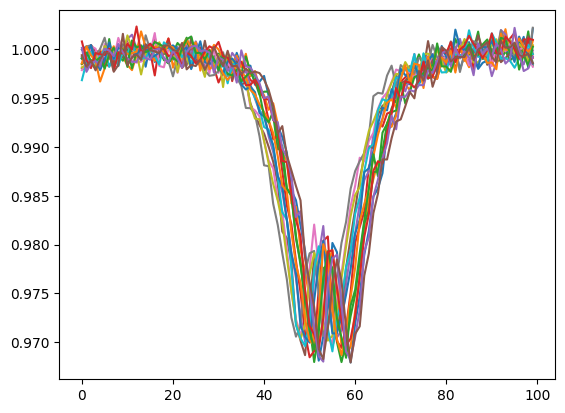

In [114]:
## import data file
fpath = '../saved_data/cycle2'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, 1:]
#df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace= True)
df.iloc[:, 2:].plot(legend= False)

# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 1:10]

#scale x axis to 0-100
sc = MinMaxScaler(feature_range=(0, 100))
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten()

torch.set_default_dtype(torch.float64)


y_esr_ = df.iloc[:, 1:]



In [115]:
df.shape
print(y_esr.columns)
print(temps)

Index(['-30 C', '-20 C up', '-10 C up', '0C up', '10 C up', '20 C up',
       '30 C up', '40 C up', '50'],
      dtype='object')
tensor([243.1500, 253.1500, 263.1500, 273.1500, 283.1500, 293.1500, 303.1500,
        313.1500, 323.1500])


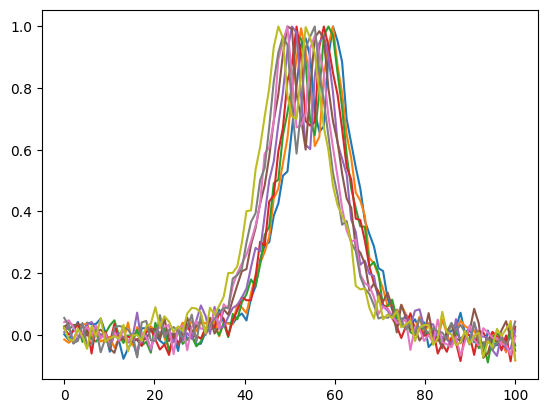

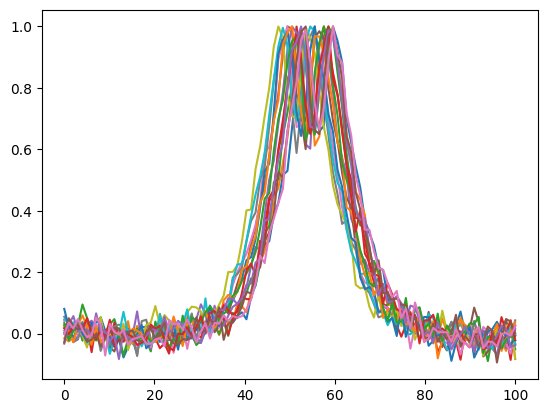

In [116]:
# plot baseline subtracted  y data
y_esr = y_esr.apply(lambda x: x - x[:20].mean())#+0.01
y_esr = -1*y_esr
y_esr = y_esr.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr); plt.show()
#plt.xlim(40, 80)

y_esr_ = y_esr_.apply(lambda x: x - x[:20].mean())#+0.01
y_esr_ = -1*y_esr_
y_esr_ = y_esr_.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr_);

In [117]:
#numpy version of function
def F_np(x_in, Amp, alpha, beta, T):
    # Reshape A, B, Amp, G1, G2 for broadcasting with x_in
    alpha = alpha[None, :]
    Amp_reshaped = Amp[None, :]
    T_reshaped = T[None, :]
    beta = beta[None, :]
    A_reshaped = (T_reshaped*alpha) + beta # Shape (1, num_samples)
    X_reshaped = 8.420054307219287
    B_reshaped = A_reshaped + X_reshaped
     # Shape (1, num_samples)
    G1_reshaped = 8.020510711744828 # New: Reshape gamma1
    G2_reshaped = 8.020510711744828 # New: Reshape gamma2
    
    x_in_reshaped = x_in[:, None] # Shape (num_x_points, 1)

    F = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G2_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G2_reshaped)**2)
    return F


# A function to sample values of A and B and plot resulting function.
def F_samples():
    amp = pyro.sample("Amp", dist.Normal(0.95, 0.25))
    alpha = pyro.sample("alpha", dist.Normal(-71, 7.0)).double() /1000
    beta = pyro.sample("beta", dist.Normal(42., 10.0)) # Sample gamma1
    T_ = torch.tensor(273.15).double()
    T = T_ * np.ones_like(alpha) 
    A =  T*alpha + beta
    B =  A + 8.420054307219287
    gamma1 =  pyro.sample("gamma1", dist.Normal(8.02, 1.0)).double()
    gamma2 = gamma1
    # Use the sampled gamma values in the function
    f_sim = lambda xi: (amp) *(0.5*gamma1)/((xi-A)**2 + (0.5*gamma1)**2) + (amp) *(0.5*gamma2)/((xi-B)**2 + (0.5*gamma2)**2)
    plt.plot(x_scale, f_sim(x_scale))
    # Update title to show sampled gamma values
    plt.title('A:' + str(A.numpy()) + ' B:' + str(B.numpy()) + ' G1:' + str(gamma1.numpy()) + ' G2:' + str(gamma2.numpy()))



## Define data we will start with and plot.

In [118]:

# this will be the data we'll start with, shown as red circles
def dataslicer(x, y, col1 =0 ,col2=1):
    x_scale_tensor = torch.tensor(x).double()
    # squeeze the selected column to produce a 1-D tensor (N,) instead of (N,1)
    y_vals = y.iloc[:, col1:col2].values.squeeze()
    y_scale_tensor = torch.tensor(y_vals).double()
    return x_scale_tensor, y_scale_tensor



(40.0, 70.0)

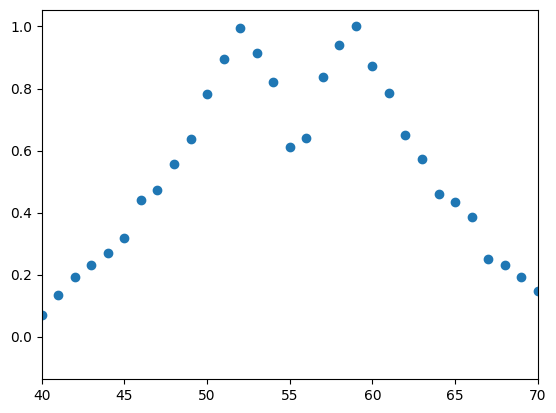

In [119]:
plt.plot(y_esr.iloc[:, 1].values, 'o')
plt.xlim(40,70)

## Set up and run Bayesian inference

In [120]:
# define the model
# Here we assume that we know the noise variance in the data = 0.1,
# though this can be set to another parameter to learn.

x_obs, y_obs = dataslicer(x_scale, y_esr, col1=0, col2=1)
T_ = 273.15 + 25.0  # Example temperature in Kelvin

data_ = (T_, (x_obs.clone().detach().double(), y_obs.clone().detach().double()))

def model(data_):
    T, data, = data_[0], data_[1]
    alpha = pyro.sample("alpha", dist.Normal(-0.077, 0.01)).double() 
    beta = pyro.sample("beta", dist.Normal(70., 10.0)) # Sample gamma1
    var = pyro.sample("var", dist.HalfNormal(scale=0.1)).double()
    gamma1 =  pyro.sample("gamma1", dist.Normal(8.02, 1.0)).double()
    A =  T*alpha + beta
    B =  A + 8.420054307219287
    #gamma1 =  8.020510711744828 
    gamma2 = gamma1#pyro.sample("gamma2", dist.Normal(8.02, 1.0)).double()
    amp =  pyro.sample("amp", dist.Normal(3., 0.25 )).double()
    
    F_ =  (amp) * (0.5 * gamma1) / ((data[0] - A)**2 + (0.5 * gamma1)**2) \
        + (amp) * (0.5 * gamma2) / ((data[0] - B)**2 + (0.5 * gamma2)**2)

    # GP hyperpriors - learnable via SVI warm-start
    lengthscale = pyro.sample("gp_lengthscale", dist.LogNormal(0., 1.0)).double()
    gp_var = pyro.sample("gp_var", dist.LogNormal(0., 1.0)).double()
    gp_noise = pyro.sample("gp_noise", dist.LogNormal(-3., 1.0)).double()

    kernel = gp.kernels.RBF(input_dim=1,
                            variance=gp_var,
                            lengthscale=lengthscale)

    # Make sure F_ is 1-D and compute residuals = observed - deterministic
    F = F_.squeeze()
    
       #with pyro.plate("data", data[0].size(0)):
    pyro.sample("obs", dist.MultivariateNormal(F, var * torch.eye(data[1].shape[0]).double()), obs=data[1])

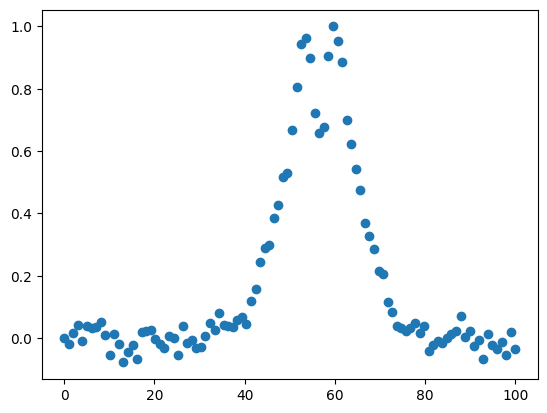

In [121]:
plt.plot(x_obs, y_obs, 'o')
#plt.xlim(40, 70)

In [122]:
temps = torch.tensor(temps).double()

C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_12868\2747252934.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  temps = torch.tensor(temps).double()


In [123]:
# solve for the posterior using MCMC
# Use the observed x positions and y values as the data passed to the model


init_vals = {
    "alpha": torch.tensor(-0.077),
    "beta": torch.tensor(71.0),
    "gamma1": torch.tensor(7.8),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),}


kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), max_tree_depth=6, ignore_jit_warnings=True)
posterior = MCMC(kernel, num_samples=200, warmup_steps=200, num_chains=1)
posterior.run((data_))



Sample: 100%|██████████| 400/400 [01:55,  3.47it/s, step size=4.06e-02, acc. prob=0.930]


#################


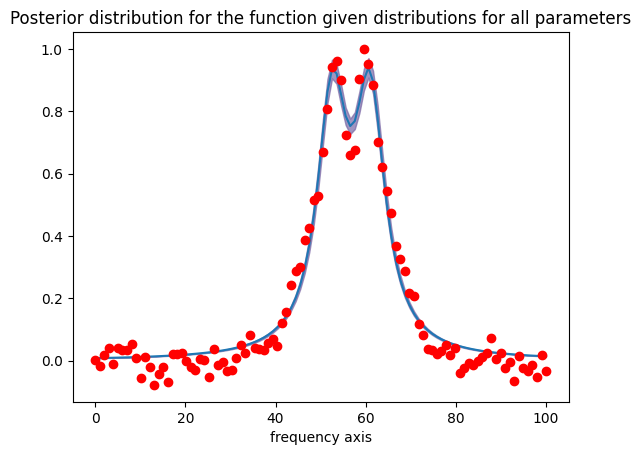

#################


In [124]:


hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
alpha = hmc_samples['alpha']
beta = hmc_samples['beta']
Amp = hmc_samples['amp'] # Get posterior samples for amp
var = hmc_samples['var'] # Get posterior samples for var
T = T_ * np.ones_like(alpha)  # Create T array matching alpha shape
F = F_np(x_scale, Amp, alpha, beta, T)
qs = mquantiles(F.T, [0.025, 0.975], axis=0)
F_mean = F.mean(axis = 1)

print('#################')
plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
plt.plot(x_scale, F_mean)
plt.plot(x_obs, y_obs, 'ro'); # plotting the data for this slice
plt.xlabel('frequency axis')
plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
pyro.clear_param_store()
print('#################')


In [125]:
print(f'alpha = {np.array(alpha).mean():.4f}')
print(f'alpha error = {np.array(alpha).var():.6f}')
print(f'beta = {np.array(beta).mean():.4f}')
print(f'beta error = {np.array(beta).var():.6f}')
print(f'gamma1 = {np.array(hmc_samples["gamma1"]).mean():.4f}')
print(f'gamma1 error = {np.array(hmc_samples["gamma1"]).var():.6f}')
print(f'amp = {np.array(hmc_samples["amp"]).mean():.4f}')
print(f'amp error = {np.array(hmc_samples["amp"]).var():.6f}')

alpha = -0.0757
alpha error = 0.000033
beta = 75.1074
beta error = 2.959791
gamma1 = 8.0965
gamma1 error = 0.054230
amp = 3.1676
amp error = 0.003075


## Get results and plot

In [126]:
[i for i in reversed(range(y_esr_.shape[1]))]


[16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]

8
{'alpha': tensor(-0.0760), 'beta': tensor(71.), 'gamma1': tensor(7.8000), 'amp': tensor(3.), 'var': tensor(0.0500)}


Sample: 100%|██████████| 400/400 [08:09,  1.22s/it, step size=1.91e-02, acc. prob=0.958]

#################


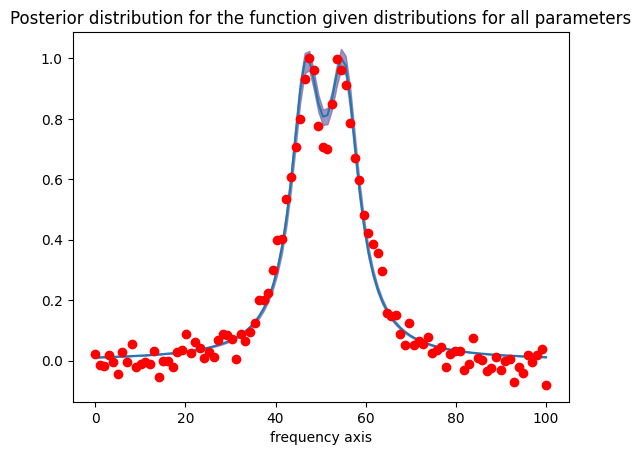

#################
7
{'alpha': tensor(-0.0742), 'beta': tensor(70.6813), 'gamma1': tensor(8.7019), 'amp': tensor(3.3833), 'var': tensor(0.0020)}


Sample: 100%|██████████| 400/400 [07:44,  1.16s/it, step size=2.24e-02, acc. prob=0.954]

#################


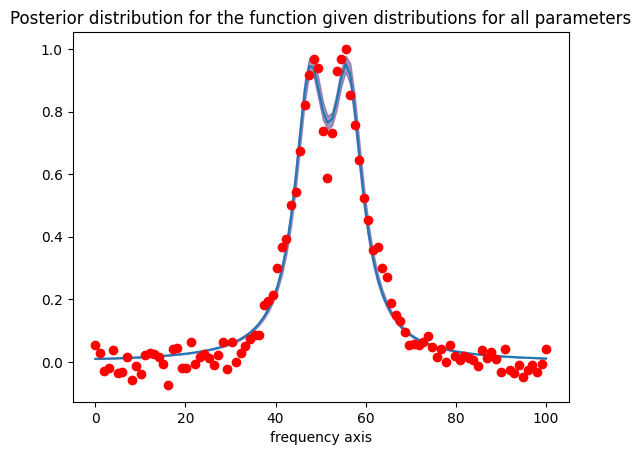

#################
6
{'alpha': tensor(-0.0754), 'beta': tensor(71.1941), 'gamma1': tensor(8.2163), 'amp': tensor(3.2126), 'var': tensor(0.0021)}


Sample: 100%|██████████| 400/400 [06:45,  1.01s/it, step size=2.46e-02, acc. prob=0.964]

#################


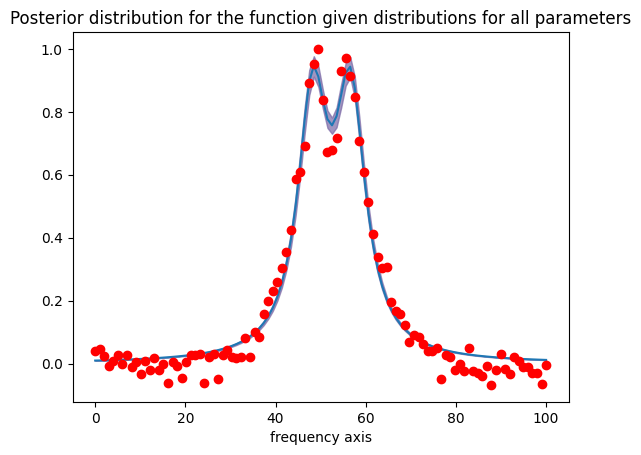

#################
5
{'alpha': tensor(-0.0754), 'beta': tensor(71.0595), 'gamma1': tensor(8.1036), 'amp': tensor(3.1892), 'var': tensor(0.0021)}


Sample: 100%|██████████| 400/400 [06:31,  1.02it/s, step size=3.63e-02, acc. prob=0.931]

#################


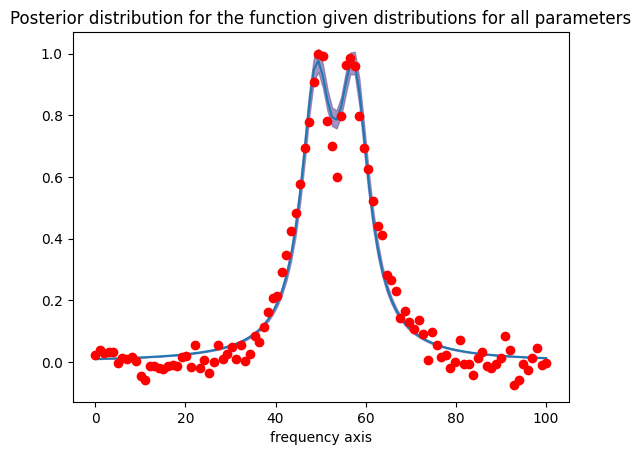

#################
4
{'alpha': tensor(-0.0783), 'beta': tensor(71.9507), 'gamma1': tensor(8.3065), 'amp': tensor(3.2976), 'var': tensor(0.0024)}


Sample: 100%|██████████| 400/400 [06:26,  1.03it/s, step size=3.00e-02, acc. prob=0.931]

#################


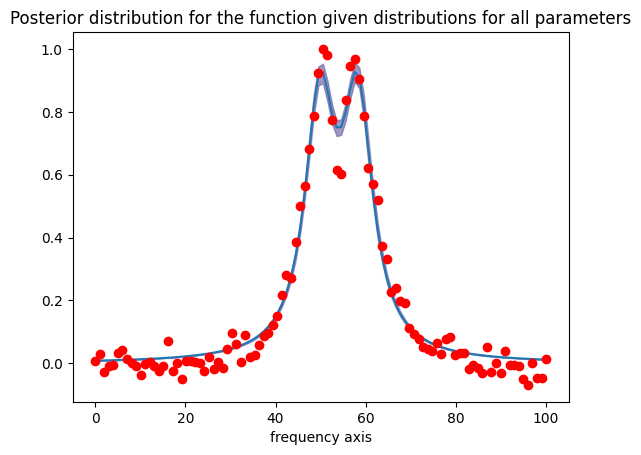

#################
3
{'alpha': tensor(-0.0772), 'beta': tensor(71.6670), 'gamma1': tensor(7.8079), 'amp': tensor(3.1386), 'var': tensor(0.0021)}


Sample: 100%|██████████| 400/400 [06:35,  1.01it/s, step size=2.46e-02, acc. prob=0.941]

#################


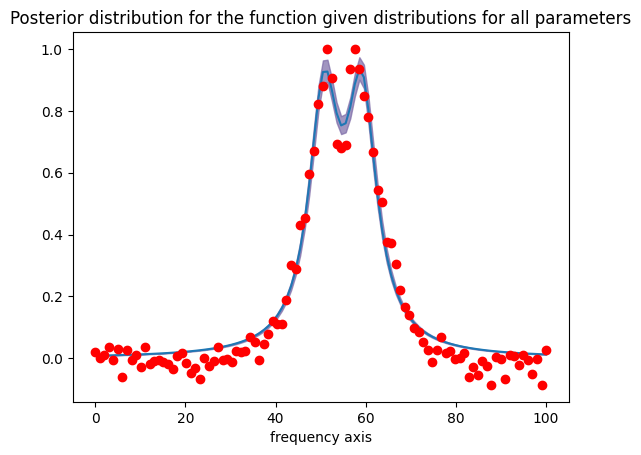

#################
2
{'alpha': tensor(-0.0781), 'beta': tensor(72.0304), 'gamma1': tensor(7.9343), 'amp': tensor(3.1580), 'var': tensor(0.0027)}


Sample: 100%|██████████| 400/400 [06:03,  1.10it/s, step size=3.53e-02, acc. prob=0.925]

#################


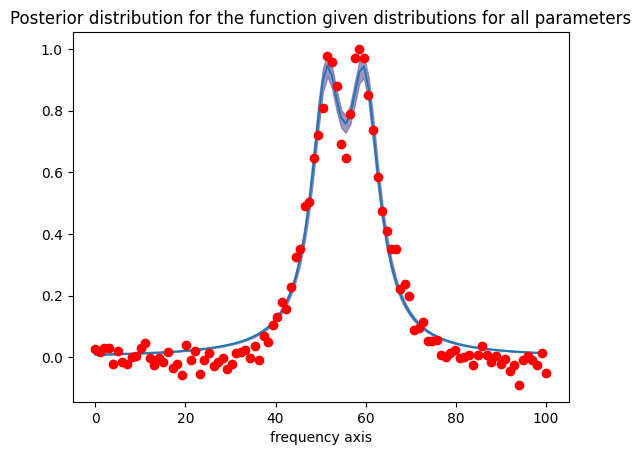

#################
1
{'alpha': tensor(-0.0776), 'beta': tensor(71.6664), 'gamma1': tensor(7.9214), 'amp': tensor(3.1903), 'var': tensor(0.0022)}


Sample: 100%|██████████| 400/400 [08:30,  1.28s/it, step size=1.61e-02, acc. prob=0.954]

#################


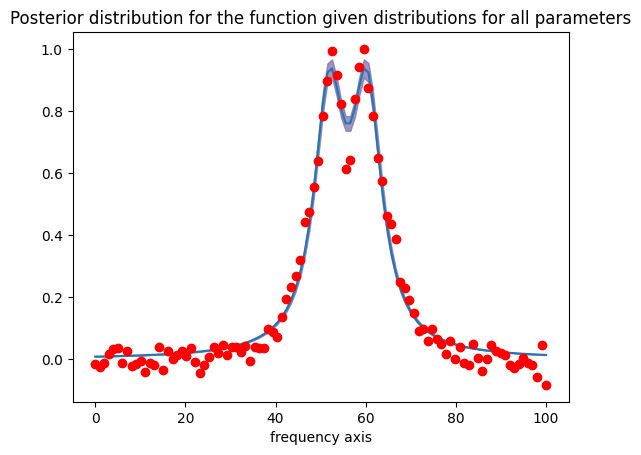

#################
0
{'alpha': tensor(-0.0778), 'beta': tensor(71.5419), 'gamma1': tensor(8.1194), 'amp': tensor(3.1769), 'var': tensor(0.0019)}


Sample: 100%|██████████| 400/400 [05:55,  1.12it/s, step size=3.44e-02, acc. prob=0.950]

#################


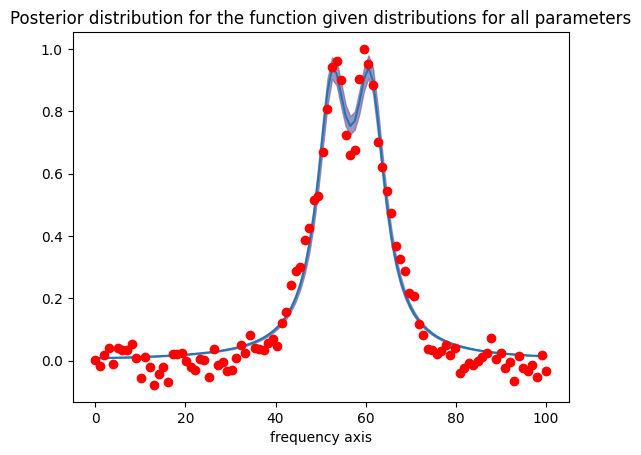

#################


In [127]:
idx = []
error_alpha = []
error_beta = []
alpha_, beta_, amp_ = [], [], []
gamma1_vals = []
beta_var, alpha_var, gamma1_var, amp_var = [], [], [], []


# init vals for MCMC
init_vals = {
    "alpha": torch.tensor(-0.076),
    "beta": torch.tensor(71.0),
    "gamma1": torch.tensor(7.8),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),}

for j in reversed(range(0, y_esr.shape[1])):
  print(j)
  print(init_vals)
  x_obs_j, y_obs_j = dataslicer(x_scale, y_esr, col1=j, col2=j+1)
  temps_j = temps[j]
  data_j_ = (temps_j, (x_obs_j[:].clone().detach().double(), y_obs_j[:].clone().detach().double()))
  kernel = NUTS(model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=9)
  posterior = MCMC(kernel, num_samples=200, warmup_steps=200, num_chains=1)
  posterior.run(data_j_)
  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  alpha = hmc_samples['alpha']
  beta = hmc_samples['beta']
  Amp = hmc_samples['amp'] # Get posterior samples for amp
  var = hmc_samples['var'] # Get posterior samples for var
  T = temps_j.item() * np.ones_like(alpha)  # Create T array matching alpha shape
  gamma1_ = hmc_samples['gamma1'] # Get posterior samples for gamma1
  gamma2_ = hmc_samples['gamma1'] # Get posterior samples for gamma2 (since gamma2 = gamma1 in the model)
  var = hmc_samples['var'] # Get posterior samples for var
  F = F_np(x_scale, Amp, alpha, beta, T)
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis = 1)
  idx.append(j)
  amp_.append(Amp.mean())  
  alpha_.append(alpha.mean())
  beta_.append(beta.mean())
  gamma1_vals.append(gamma1_.mean())
  alpha_var.append(alpha.var())
  beta_var.append(beta.var())
  gamma1_var.append(gamma1_.var())
  amp_var.append(Amp.var())
  print('#################')
  plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6")
  plt.plot(x_scale, F_mean)
  plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  #pyro.clear_param_store()
  init_vals = {
      "alpha": torch.tensor(alpha.mean()),
      "beta": torch.tensor(beta.mean()),
      "gamma1": torch.tensor(gamma1_.mean()),
      "amp": torch.tensor(Amp.mean()),
      "var": torch.tensor(var.mean()),}    
  print('#################')


In [128]:
print(f'alpha = {np.array(alpha_).mean():.4f}')
print(f'alpha error = {np.array(alpha_var).mean():.6f}')

print(f'beta = {np.array(beta_).mean():.4f}')
print(f'beta error = {np.array(beta_var).mean():.6f}')


print(f'gamma1 = {np.array(gamma1_).mean():.4f}')
print(f'gamma1 error = {np.array(gamma1_var).mean():.6f}')

alpha = -0.0767
alpha error = 0.000087
beta = 71.4243
beta error = 7.048630
gamma1 = 8.0733
gamma1 error = 0.075128


In [129]:
### define the calibrated model using learned alpha, beta and gamma parameters from the MCMC runs above, and use it to predict T for calibration data

def calibrated_model(data_):
    data = data_
    # Use learned calibration parameters (fixed from calibration phase)
    alpha = torch.tensor(np.array(alpha_).mean()).double()
    beta = torch.tensor(np.array(beta_).mean()).double()
    gamma1 = torch.tensor(np.array(gamma1_vals).mean()).double()
    # Sample observation noise variance
    var = pyro.sample("var", dist.HalfNormal(scale=0.1)).double()
    # Sample amplitude with informative prior
    amp = pyro.sample("amp", dist.Normal(3., 0.25)).double()
    # Sample temperature (prior from broad range, will be refined by data and GP)
    T_ = pyro.sample("T_", dist.Uniform(242, 344)).double()
    # T_ = T_ * np.ones_like(alpha)  # Create T array matching alpha shape
    A = T_ * alpha + beta
    B = A + 7.9
    gamma2 = gamma1
    F_ = (amp) * (0.5 * gamma1) / ((data[0] - A)**2 + (0.5 * gamma1)**2) \
        + (amp) * (0.5 * gamma2) / ((data[0] - B)**2 + (0.5 * gamma2)**2)
    F_ = F_.squeeze()
    # Observe data
    pyro.sample("obs", dist.MultivariateNormal(F_, var * torch.eye(data[1].shape[0]).double()), obs=data[1])

In [130]:
#numpy version of function
def F_np_calibrated(x_in, Amp, gamma, T):
    # Reshape A, B, Amp, G1, G2 for broadcasting with x_in
    alpha = np.array(alpha_).mean()
    Amp_reshaped = Amp[None, :]
    T_reshaped = T[None, :]
    beta = np.array(beta_).mean()
    A_reshaped = (T_reshaped*alpha) + beta # Shape (1, num_samples)
    X_reshaped = 7.9
    B_reshaped = A_reshaped + X_reshaped
     # Shape (1, num_samples)
    G1_reshaped = gamma[None, :] # New: Reshape gamma1
    G2_reshaped = gamma[None, :] # New: Reshape gamma2

    x_in_reshaped = x_in[:, None] # Shape (num_x_points, 1)

    F = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G2_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G2_reshaped)**2)
    
    
    return F


# A function to sample values of A and B and plot resulting function.
def F_calibrated_samples():
    alpha = torch.tensor(np.array(alpha_).mean()).double()
    beta = torch.tensor(np.array(beta_).mean()).double()
    var = pyro.sample("var", dist.HalfNormal(scale=0.1)).double()
    gamma1 =  pyro.sample("gamma1", dist.Normal(8.02, 1.0)).double()
    T = pyro.sample("T", dist.Uniform(242, 343)).double() * torch.ones_like(alpha)
    A =  T*alpha + beta
    B =  A + 7.9
    gamma2 = gamma1#pyro.sample("gamma2", dist.Normal(8.02, 1.0)).double()
    amp =  pyro.sample("amp", dist.Normal(1.25, 0.25 )).double()
    
    f_sim = lambda xi: (amp) *(0.5*gamma1)/((xi-A)**2 + (0.5*gamma1)**2) + (amp) *(0.5*gamma2)/((xi-B)**2 + (0.5*gamma2)**2)
    plt.plot(x_scale, f_sim(x_scale))
    # Update title to show sampled gamma values
    plt.title('A:' + str(A.numpy()) + ' B:' + str(B.numpy()) + ' G1:' + str(gamma1.numpy()) + ' G2:' + str(gamma2.numpy()))

0


Sample: 100%|██████████| 400/400 [00:11, 35.96it/s, step size=6.01e-01, acc. prob=0.908]


#################
experimental temperature: 243.15 K, inferred temperature: 243.61 K


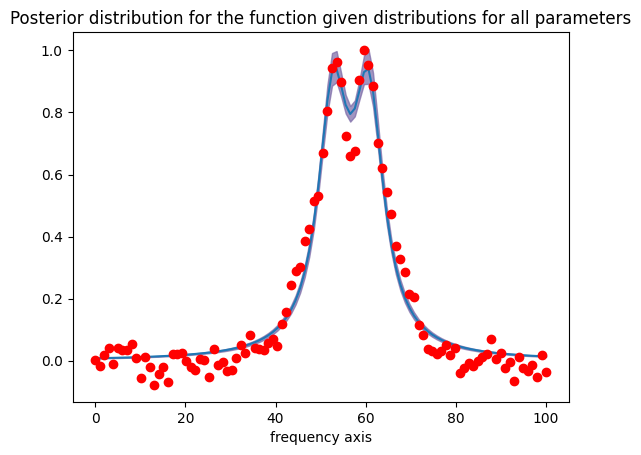

#################
1


Sample: 100%|██████████| 400/400 [00:07, 54.63it/s, step size=8.65e-01, acc. prob=0.886]


#################
experimental temperature: 253.15 K, inferred temperature: 251.81 K


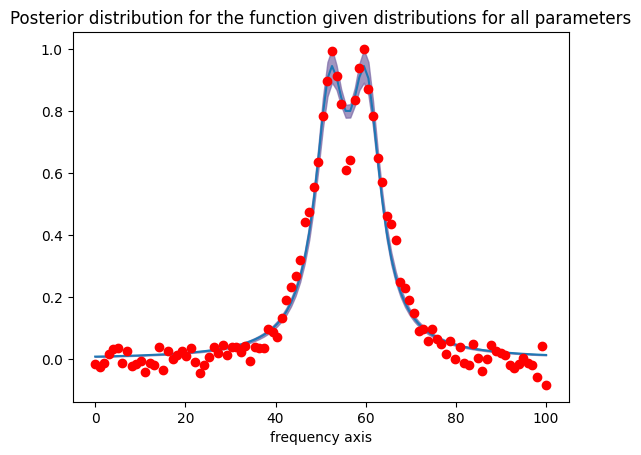

#################
2


Sample: 100%|██████████| 400/400 [00:06, 59.26it/s, step size=8.20e-01, acc. prob=0.904]


#################
experimental temperature: 263.15 K, inferred temperature: 259.82 K


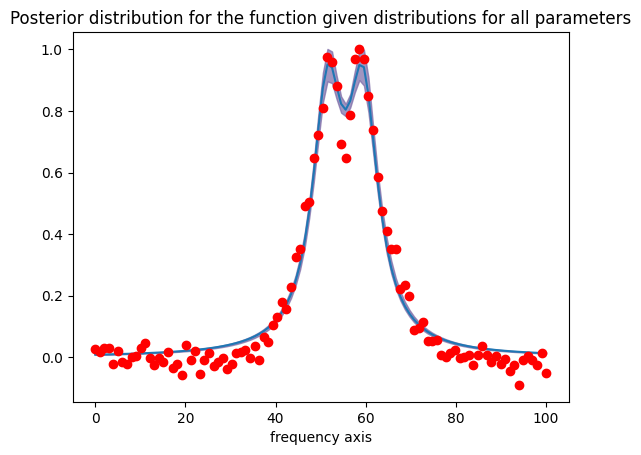

#################
3


Sample: 100%|██████████| 400/400 [00:07, 55.17it/s, step size=7.61e-01, acc. prob=0.919]


#################
experimental temperature: 273.15 K, inferred temperature: 267.06 K


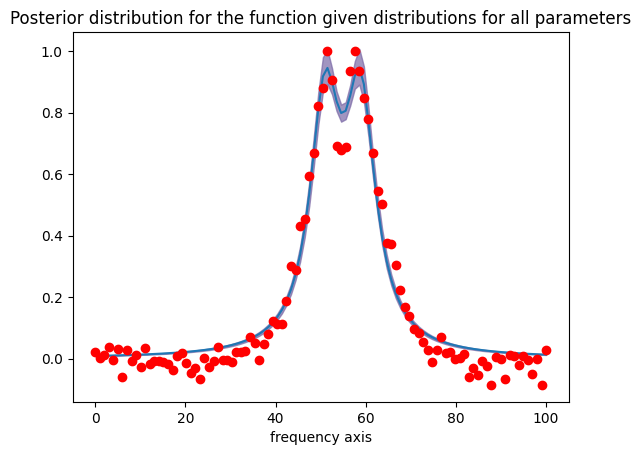

#################
4


Sample: 100%|██████████| 400/400 [00:06, 60.88it/s, step size=8.81e-01, acc. prob=0.911]


#################
experimental temperature: 283.15 K, inferred temperature: 278.60 K


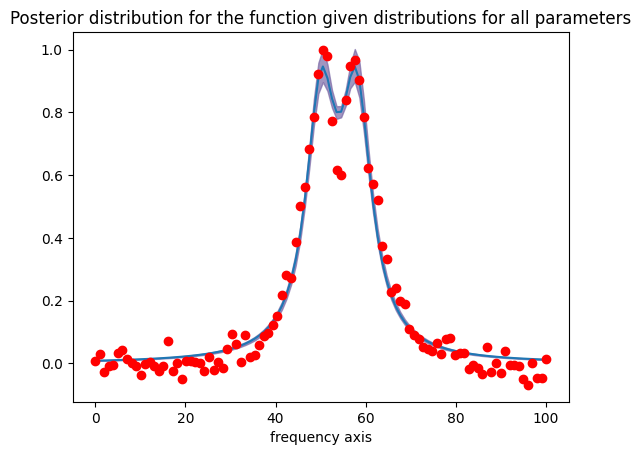

#################
5


Sample: 100%|██████████| 400/400 [00:06, 58.28it/s, step size=7.30e-01, acc. prob=0.924]


#################
experimental temperature: 293.15 K, inferred temperature: 289.40 K


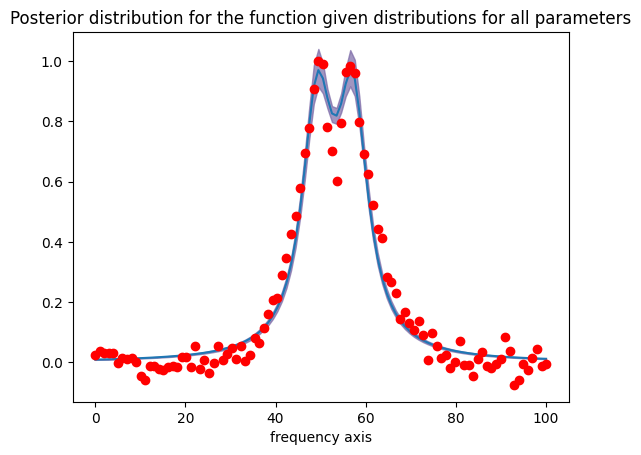

#################
6


Sample: 100%|██████████| 400/400 [00:07, 56.99it/s, step size=6.17e-01, acc. prob=0.949]


#################
experimental temperature: 303.15 K, inferred temperature: 299.31 K


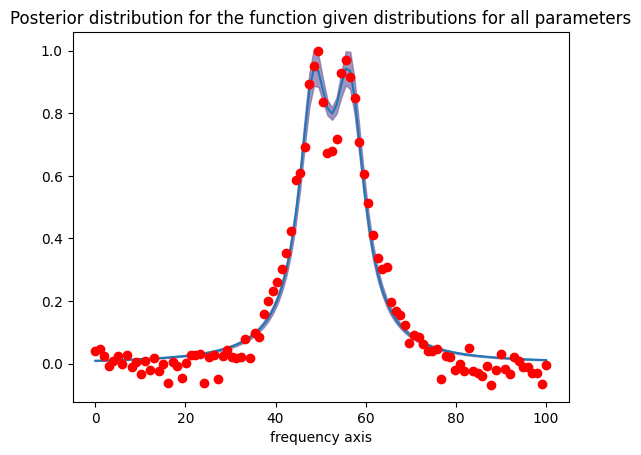

#################
7


Sample: 100%|██████████| 400/400 [00:07, 55.02it/s, step size=7.20e-01, acc. prob=0.930]


#################
experimental temperature: 313.15 K, inferred temperature: 307.42 K


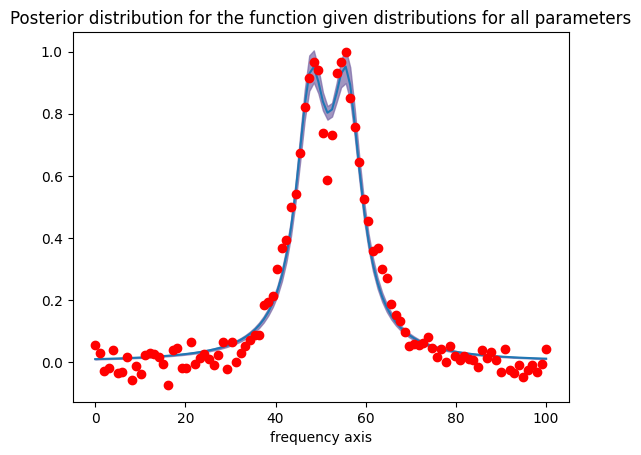

#################
8


Sample: 100%|██████████| 400/400 [00:06, 58.66it/s, step size=9.12e-01, acc. prob=0.903]


#################
experimental temperature: 323.15 K, inferred temperature: 318.92 K


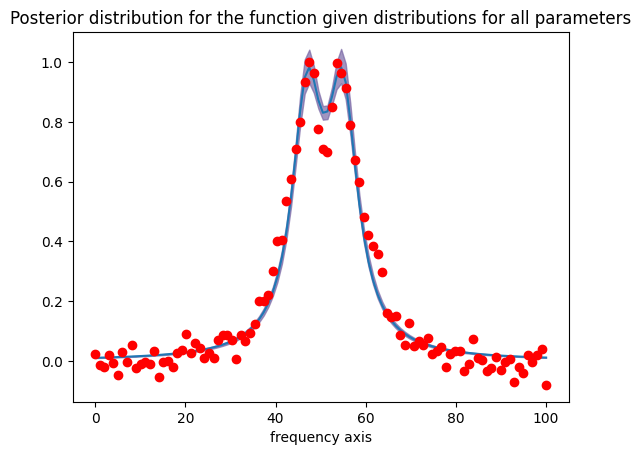

#################


In [131]:
idx = []
temp_, amp_ = [], []
amp_var = []
temp_var = []
temp_ci_high, temp_ci_low = [], []


# init vals for MCMC

init_vals = {
    "T_": torch.tensor(300.),
    "gamma1": torch.tensor(7.8),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),}


for j in range(0, y_esr.shape[1]):
  print(j)
  x_obs_j, y_obs_j = dataslicer(x_scale, y_esr_, col1=j, col2=j+1)
  temps_j = temp_test_array[j]
  data_j = (x_obs_j.clone().detach().double(), y_obs_j.clone().detach().double())
  # print(y_obs_j.shape)
  kernel = NUTS(calibrated_model, jit_compile=True, init_strategy=init_to_value(values=init_vals), ignore_jit_warnings=True, max_tree_depth=6)
  posterior = MCMC(kernel, num_samples=200, warmup_steps=200, num_chains=1)
  posterior.run(data_j)
  hmc_samples = {k: v.detach().cpu().numpy() for k, v in posterior.get_samples().items()}
  T = hmc_samples['T_']
  Amp = hmc_samples['amp'] # Get posterior samples for amp
  var = hmc_samples['var'] # Get posterior samples for var
  F = F_np_calibrated(x_scale, Amp, gamma1_, T)
  qs = mquantiles(F.T, [0.025, 0.975], axis=0)
  F_mean = F.mean(axis = 1)
  idx.append(j)
  amp_.append(Amp.mean())  
  temp_.append(T.mean())
  temp_var.append(T.var())
  amp_var.append(Amp.var())
  T_ci = np.quantile(T, [0.025, 0.975])
  temp_ci_low.append(T_ci[0])
  temp_ci_high.append(T_ci[1])
  print('#################')
  print(f'experimental temperature: {temps_j.item():.2f} K, inferred temperature: {T.mean():.2f} K')
  plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6");
  plt.plot(x_scale, F_mean)
  plt.plot(x_obs_j, y_obs_j, 'ro'); # plotting the data for this slice
  plt.xlabel('frequency axis')
  plt.title('Posterior distribution for the function given distributions for all parameters');plt.show()
  #pyro.clear_param_store()
 
  print('#################')

In [132]:
print(f'amp = {np.array(amp_).mean():.4f}')
print(f'amp error = {np.array(amp_var).mean():.6f}')

print(f'gamma1 = {np.array(gamma1_vals).mean():.4f}')
print(f'gamma1 error = {np.array(gamma1_var).mean():.6f}')

print(f'Temperature = {np.array(temp_).mean():.2f} K')
print(f'Temperature error = {np.array(temp_var).mean():.6f}')

amp = 3.1735
amp error = 0.001929
gamma1 = 8.1316
gamma1 error = 0.075128
Temperature = 279.55 K
Temperature error = 2.312670


C:\Users\zahmed\AppData\Local\Temp\1\ipykernel_12868\936701079.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.plot(np.array(temp_test[:]), 'ro--')


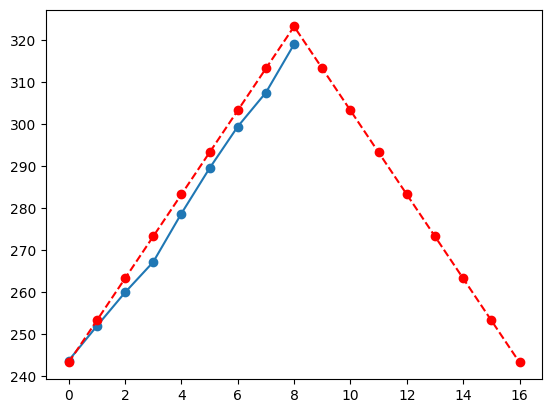

In [133]:
temperature = np.asarray(temp_)
plt.plot(temperature, 'o-')
plt.plot(np.array(temp_test[:]), 'ro--')

In [134]:
# plt.plot(np.array(temp_test[9:]), temperature[9:], 'k*')
# plt.xlabel('Experimental Temperature (K)')
# plt.ylabel('Inferred Temperature (K)')
# import seaborn as sns
# sns.regplot(x = np.array(temp_test[:9]), y = temperature[:9])

In [135]:
np.sqrt(np.mean((np.asarray(temp_test[:len(temperature)]) -  temperature)**2))

np.float64(4.08778785844535)

In [136]:
### define the calibrated model using learned GP

def affine_model(T_samples, T_exp):
    a = pyro.sample("a", dist.Normal(0., 0.1))
    b = pyro.sample("b", dist.Normal(0.0, 5.0))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.0))

    T_corr = a * T_samples + b

    pyro.sample( "obs", dist.Normal(T_corr, sigma), obs=T_exp.expand_as(T_corr),)


In [137]:
#numpy version of function
def F_np_affine(T_, a,b):
    # Reshape A, B, Amp, G1, G2 for broadcasting with x_in
    T = np.array(T_).mean()
    a_reshaped = a[None, :]
    b_reshaped = b[None, :]
    beta = np.array(beta_).mean()
    T = a_reshaped*T_ + b_reshaped
    
    return T


In [161]:
idx = []

temp_mean_raw = []
temp_ci_low_raw = []
temp_ci_high_raw = []

temp_mean_corr = []
temp_ci_low_corr = []
temp_ci_high_corr = []

a_hat = []
b_hat = []
init_vals_affine = {    "a": torch.tensor(0.75),
    "b": torch.tensor(60.0),}



for j in range(y_esr.shape[1]):

    print(f"\n===== Spectrum {j} =====")

    # -----------------------
    # Slice data
    # -----------------------
    x_obs_j, y_obs_j = dataslicer(
        x_scale, y_esr_, col1=j, col2=j+1
    )

    data_j = (
        x_obs_j.clone().detach().double(),
        y_obs_j.clone().detach().double(),
    )

    T_exp = torch.tensor(
        temp_test_array[j],
        dtype=torch.double
    )

    # -----------------------
    # Phase 1: Physics model
    # -----------------------
    kernel = NUTS(
        calibrated_model,
        
        max_tree_depth=6,
        jit_compile=True,
        ignore_jit_warnings=True,
    )

    mcmc = MCMC(
        kernel,
        num_samples=500,
        warmup_steps=500,
        num_chains=1,
    )

    mcmc.run(data_j)
    samples = mcmc.get_samples()

    T_samples = samples["T_"].detach().cpu().flatten()

    # Raw posterior summary
    T_ci = np.quantile(T_samples.numpy(), [0.025, 0.975])

    temp_mean_raw.append(T_samples.mean().item())
    temp_ci_low_raw.append(T_ci[0])
    temp_ci_high_raw.append(T_ci[1])

    print(
        f"Experimental T: {T_exp.item():.2f} K | "
        f"Inferred T: {T_samples.mean():.2f} K"
    )

    # -----------------------
    # Phase 2: Affine calibration
    # -----------------------
    kernel_aff = NUTS(
        affine_model,
       
    )

    mcmc_aff = MCMC(
        kernel_aff,
        num_samples=1000,
        warmup_steps=500,
        num_chains=1,
    )

    mcmc_aff.run(T_samples, T_exp)

    aff_samples = mcmc_aff.get_samples()

    a_mean = aff_samples["a"].mean().item()
    b_mean = aff_samples["b"].mean().item()

    a_hat.append(a_mean)
    b_hat.append(b_mean)
    

    print(f"Affine correction: a = {a_mean:.3f}, b = {b_mean:.3f}")

    # -----------------------
    # Apply correction
    # -----------------------
    T_corrected = a_mean * T_samples + b_mean

    T_ci_corr = np.quantile(T_corrected.numpy(), [0.025, 0.975])

    temp_mean_corr.append(T_corrected.mean().item())
    temp_ci_low_corr.append(T_ci_corr[0])
    temp_ci_high_corr.append(T_ci_corr[1])

    print(
        f"Corrected T mean: {T_corrected.mean():.2f} K"
    )

    idx.append(j)



===== Spectrum 0 =====


Sample: 100%|██████████| 1000/1000 [00:24, 40.44it/s, step size=5.23e-01, acc. prob=0.902]


Experimental T: 243.15 K | Inferred T: 243.81 K


Sample: 100%|██████████| 1500/1500 [22:10,  1.13it/s, step size=3.14e-03, acc. prob=0.951]


Affine correction: a = 0.646, b = 85.694
Corrected T mean: 243.15 K

===== Spectrum 1 =====


...

Affine correction: a = 0.837, b = 55.788
Corrected T mean: 313.15 K

===== Spectrum 8 =====


Sample: 100%|██████████| 1000/1000 [00:19, 51.46it/s, step size=6.86e-01, acc. prob=0.938]


Experimental T: 323.15 K | Inferred T: 319.00 K


Sample: 100%|██████████| 1500/1500 [12:33,  1.99it/s, step size=7.91e-03, acc. prob=0.940]

Affine correction: a = 0.848, b = 52.746
Corrected T mean: 323.14 K


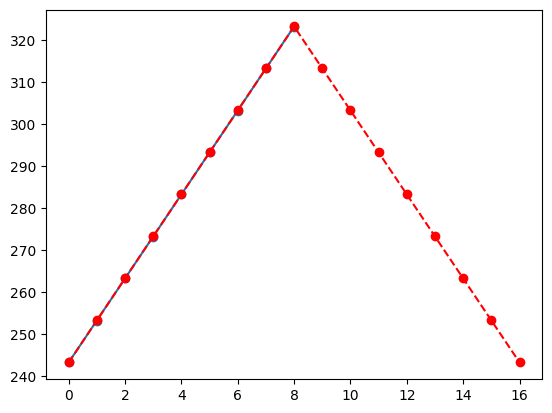

In [162]:
temperature = np.asarray(temp_mean_corr)
plt.plot(temperature, 'o-')
plt.plot(np.asarray(temp_test[:]), 'ro--')

In [164]:
a_mean = np.asarray(a_hat).mean()
b_mean = np.asarray(b_hat).mean()
print(f'a = {a_mean:.3f}, b = {b_mean:.3f}')

a = 0.771, b = 66.144


In [165]:
mean_squared_error = np.mean((np.asarray(temp_test[:len(temperature)]) -  temperature)**2)
print(f'RMSE after calibration: {np.sqrt(mean_squared_error):.2f} K')

RMSE after calibration: 0.01 K


Linear regression coefficients: a = 1.050, b = -10.254


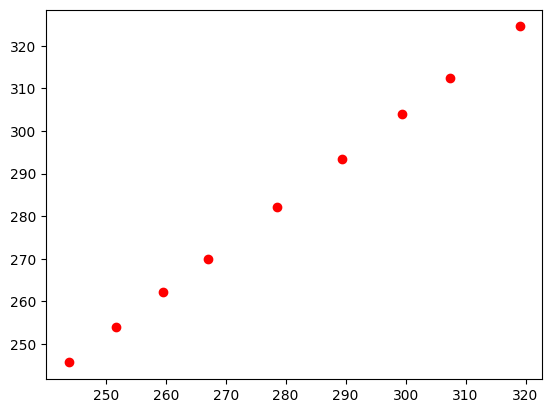

In [167]:
# build a linear regression model 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Fit linear regression to raw inferred temperatures
X_raw = np.asarray(temp_mean_raw).reshape(-1, 1)  
y_raw = np.asarray(temp_test[:len(temp_mean_raw)])

ln = LinearRegression()
ln.fit(X_raw, y_raw)
y_pred = ln.predict(X_raw)
plt.plot(X_raw, y_pred, 'ro', label='correction')

print(f'Linear regression coefficients: a = {ln.coef_[0]:.3f}, b = {ln.intercept_:.3f}')

In [179]:
# apply learned linear regression correction to raw inferred temperatures
a, b = ln.coef_[0], ln.intercept_

idx = []

temp_mean_raw = []
temp_ci_low_raw = []
temp_ci_high_raw = []

temp_mean_corr = []
temp_ci_low_corr = []
temp_ci_high_corr = []

a_hat = []
b_hat = []




for j in range(y_esr_.shape[1]):

    print(f"\n===== Spectrum {j} =====")

    # -----------------------
    # Slice data
    # -----------------------
    x_obs_j, y_obs_j = dataslicer(
        x_scale, y_esr_, col1=j, col2=j+1
    )

    data_j = (
        x_obs_j.clone().detach().double(),
        y_obs_j.clone().detach().double(),
    )

    T_exp = torch.tensor(
        temp_test_array[j],
        dtype=torch.double
    )

    # -----------------------
    # Phase 1: Physics model
    # -----------------------
    kernel = NUTS(
        calibrated_model,
        
        max_tree_depth=6,
        jit_compile=True,
        ignore_jit_warnings=True,
    )

    mcmc = MCMC(
        kernel,
        num_samples=500,
        warmup_steps=500,
        num_chains=1,
    )

    mcmc.run(data_j)
    samples = mcmc.get_samples()

    T_samples = samples["T_"].detach().cpu().flatten()

    # Raw posterior summary
    T_ci = np.quantile(T_samples.numpy(), [0.025, 0.975])

    temp_mean_raw.append(T_samples.mean().item())
    temp_ci_low_raw.append(T_ci[0])
    temp_ci_high_raw.append(T_ci[1])

    print(
        f"Experimental T: {T_exp.item():.2f} K | "
        f"Inferred T (pre_correction): {T_samples.mean():.2f} K"
    )


    # -----------------------
    # Apply correction
    # -----------------------
    T_corrected =  (T_samples * a) + b 

    T_ci_corr = np.quantile(T_corrected.numpy(), [0.025, 0.975])

    temp_mean_corr.append(T_corrected.mean().item())
    temp_ci_low_corr.append(T_ci_corr[0])
    temp_ci_high_corr.append(T_ci_corr[1])

    print(
        f"Corrected T mean: {T_corrected.mean():.2f} K"
    )

    idx.append(j)



===== Spectrum 0 =====


Sample: 100%|██████████| 1000/1000 [00:24, 41.55it/s, step size=5.73e-01, acc. prob=0.864]


Experimental T: 243.15 K | Inferred T (pre_correction): 243.66 K
Corrected T mean: 245.48 K

===== Spectrum 1 =====


Sample: 100%|██████████| 1000/1000 [00:17, 55.91it/s, step size=8.79e-01, acc. prob=0.879]


Experimental T: 253.15 K | Inferred T (pre_correction): 251.79 K
Corrected T mean: 254.01 K

===== Spectrum 2 =====


...

Experimental T: 263.15 K | Inferred T (pre_correction): 260.23 K
Corrected T mean: 262.87 K

===== Spectrum 15 =====


Sample: 100%|██████████| 1000/1000 [00:16, 58.88it/s, step size=8.82e-01, acc. prob=0.890]


Experimental T: 253.15 K | Inferred T (pre_correction): 250.90 K
Corrected T mean: 253.08 K

===== Spectrum 16 =====


Sample: 100%|██████████| 1000/1000 [00:24, 40.86it/s, step size=4.34e-01, acc. prob=0.885]

Experimental T: 243.15 K | Inferred T (pre_correction): 244.76 K
Corrected T mean: 246.64 K


In [180]:
 temp_test_array - temp_mean_corr

array([-2.33023364, -0.86459343,  0.73888071,  3.05430392,  1.14358248,
       -0.31319821, -0.78699769,  0.66419961, -1.24668538,  0.86472258,
        1.85198424,  0.99392968,  2.347223  ,  2.21875588,  0.27856766,
        0.07489794, -3.48666616])

RMSE after linear regression correction: 1.68 K


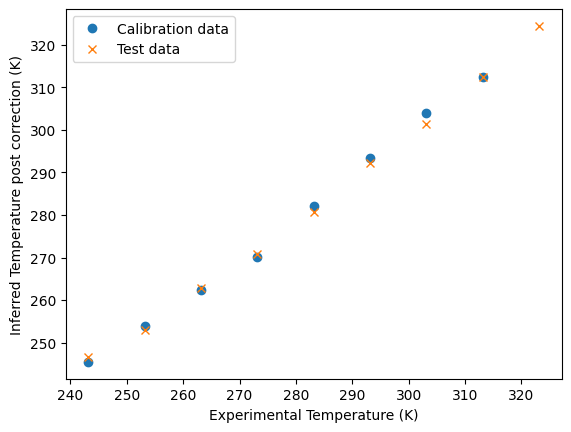

In [183]:
plt.plot(temp_test_array[:8], np.asarray(temp_mean_corr[:8]), 'o')
plt.plot(temp_test_array[8:], np.asarray(temp_mean_corr[8:]), 'x')
plt.xlabel('Experimental Temperature (K)')
plt.ylabel('Inferred Temperature post correction (K)')
plt.legend(['Calibration data', 'Test data'])

mean_squared_error = np.mean((np.asarray(temp_test) -  np.asarray(temp_mean_corr))**2)
print(f'RMSE after linear regression correction: {np.sqrt(mean_squared_error):.2f} K')

In [184]:
# apply learned bayesian affine correction to raw inferred temperatures

idx = []

temp_mean_raw = []
temp_ci_low_raw = []
temp_ci_high_raw = []

temp_mean_corr = []
temp_ci_low_corr = []
temp_ci_high_corr = []

a_hat = []
b_hat = []
init_vals_affine = {    "a": torch.tensor(0.75),
    "b": torch.tensor(60.0),}



for j in range(y_esr_.shape[1]):

    print(f"\n===== Spectrum {j} =====")

    # -----------------------
    # Slice data
    # -----------------------
    x_obs_j, y_obs_j = dataslicer(
        x_scale, y_esr_, col1=j, col2=j+1
    )

    data_j = (
        x_obs_j.clone().detach().double(),
        y_obs_j.clone().detach().double(),
    )

    T_exp = torch.tensor(
        temp_test_array[j],
        dtype=torch.double
    )

    # -----------------------
    # Phase 1: Physics model
    # -----------------------
    kernel = NUTS(
        calibrated_model,
        
        max_tree_depth=6,
        jit_compile=True,
        ignore_jit_warnings=True,
    )

    mcmc = MCMC(
        kernel,
        num_samples=500,
        warmup_steps=500,
        num_chains=1,
    )

    mcmc.run(data_j)
    samples = mcmc.get_samples()

    T_samples = samples["T_"].detach().cpu().flatten()

    # Raw posterior summary
    T_ci = np.quantile(T_samples.numpy(), [0.025, 0.975])

    temp_mean_raw.append(T_samples.mean().item())
    temp_ci_low_raw.append(T_ci[0])
    temp_ci_high_raw.append(T_ci[1])

    print(
        f"Experimental T: {T_exp.item():.2f} K | "
        f"Inferred T (pre_correction): {T_samples.mean():.2f} K"
    )


    # -----------------------
    # Apply correction
    # -----------------------
    T_corrected = a_mean * T_samples + b_mean

    T_ci_corr = np.quantile(T_corrected.numpy(), [0.025, 0.975])

    temp_mean_corr.append(T_corrected.mean().item())
    temp_ci_low_corr.append(T_ci_corr[0])
    temp_ci_high_corr.append(T_ci_corr[1])

    print(
        f"Corrected T mean: {T_corrected.mean():.2f} K"
    )

    idx.append(j)



===== Spectrum 0 =====


Sample: 100%|██████████| 1000/1000 [00:26, 37.59it/s, step size=4.30e-01, acc. prob=0.922]


Experimental T: 243.15 K | Inferred T (pre_correction): 243.63 K
Corrected T mean: 253.94 K

===== Spectrum 1 =====


Sample: 100%|██████████| 1000/1000 [00:17, 56.47it/s, step size=9.57e-01, acc. prob=0.888]


Experimental T: 253.15 K | Inferred T (pre_correction): 251.79 K
Corrected T mean: 260.23 K

===== Spectrum 2 =====


...

Experimental T: 263.15 K | Inferred T (pre_correction): 260.05 K
Corrected T mean: 266.60 K

===== Spectrum 15 =====


Sample: 100%|██████████| 1000/1000 [00:18, 54.44it/s, step size=7.09e-01, acc. prob=0.935]


Experimental T: 253.15 K | Inferred T (pre_correction): 250.84 K
Corrected T mean: 259.50 K

===== Spectrum 16 =====


Sample: 100%|██████████| 1000/1000 [00:26, 37.45it/s, step size=3.95e-01, acc. prob=0.942]

Experimental T: 243.15 K | Inferred T (pre_correction): 244.77 K
Corrected T mean: 254.82 K


RMSE after Bayesian regression correction: 7.07 K


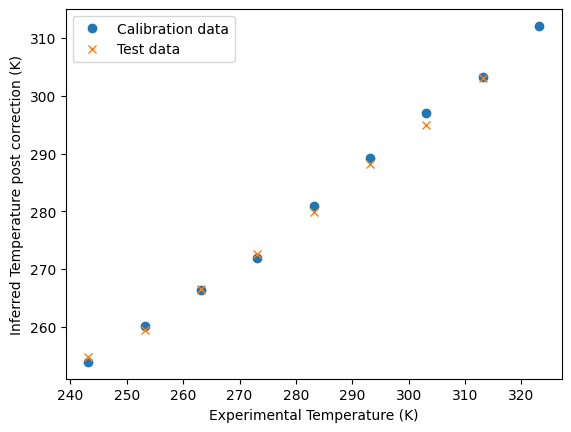

In [186]:
plt.plot(temp_test_array[:9], np.asarray(temp_mean_corr[:9]), 'o')
plt.plot(temp_test_array[9:], np.asarray(temp_mean_corr[9:]), 'x')
plt.xlabel('Experimental Temperature (K)')
plt.ylabel('Inferred Temperature post correction (K)')
plt.legend(['Calibration data', 'Test data'])

mean_squared_error = np.mean((np.asarray(temp_test) -  np.asarray(temp_mean_corr))**2)
print(f'RMSE after Bayesian regression correction: {np.sqrt(mean_squared_error):.2f} K')

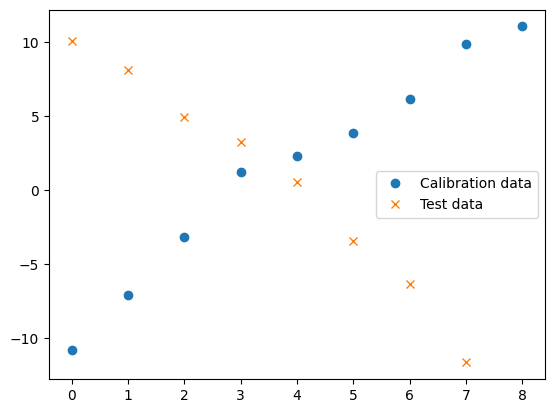

In [189]:
plt.plot(temp_test_array[:9] - np.asarray(temp_mean_corr[:9]), 'o')
plt.plot(temp_test_array[9:]- np.asarray(temp_mean_corr[9:]), 'x')
plt.legend(['Calibration data', 'Test data'])